# Tarea M3 · Regresión aplicada a un ramo de seguros

**Equipo 3**

Integrantes:

-
- Ruiz Carbajal Ismael
-


---

## 1. Selección del ramo y justificación

Se evaluaron los cuatro ramos disponibles en la cartera (`GMM`, `Autos`, `Vida`, `Accidentes Personales`). En un primer avance se había seleccionado **Autos**, pero al revisar la prima se detectaron valores poco consistentes para ese ramo, y ya existía trabajo previo del equipo (encoding de variables) sobre **GMM** en otro ejercicio del diplomado. Por ello el equipo decide trabajar con el ramo de **Gastos Médicos Mayores (GMM)**, justificado por:

- Es el ramo con mayor número de observaciones de la cartera (22,531 pólizas de 50,000, ~45%).
- Sus variables clave (`suma_asegurada`, `deducible`, `prima_neta`, `prima_total`, `n_siniestros`, `monto_pagado`) tienen muy pocos o nulos valores faltantes, a diferencia de Autos, donde `marca_vehiculo`/`tipo_vehiculo` faltan en el 100% de las pólizas que no son de Autos y complican comparaciones cruzadas.
- Tiene variables categóricas relevantes para tarificación (`plan`, `nivel_riesgo`, `ocupacion`) que permiten construir modelos de regresión múltiple y logística con sentido actuarial.
- Continuidad de trabajo en equipo: parte del preprocesamiento (codificación de variables categóricas) ya se había explorado en un ejercicio anterior con este mismo ramo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

cartera = pd.read_parquet("cartera_q1_2026_final.parquet")
cartera["ramo"].value_counts()

ramo
GMM                      22531
Autos                    14752
Vida                      7510
Accidentes Personales     5207
Name: count, dtype: int64

In [2]:
cartera.groupby("ramo").agg(
    polizas=("id_poliza", "count"),
    prima_promedio=("prima_total", "mean"),
    siniestros_promedio=("n_siniestros", "mean"),
    monto_reclamado=("monto_reclamado", "mean"),
    loss_ratio=("loss_ratio", "mean")
).round(2)

,polizas,prima_promedio,siniestros_promedio,monto_reclamado,loss_ratio
ramo,,,,,
Accidentes Personales,5207,4797.52,0.35,12990.09,0.41
Autos,14752,17206.04,0.36,13473.50,0.25
GMM,22531,32445.18,0.36,13403.79,0.20
Vida,7510,60496.95,0.36,12780.06,0.12


## 2. Análisis exploratorio (EDA)

Se reutiliza y adapta la clase `AnalizadorRamo` construida previamente por el equipo para el ramo de Autos. Se sustituyen los gráficos específicos de vehículo (`marca_vehiculo`, `tipo_vehiculo`, que no existen para GMM) por variables propias de este ramo: `ocupacion` y `nivel_riesgo`.

In [3]:
class AnalizadorRamo:

    def __init__(self, dataframe, nombre_ramo):
        self.df_completo = dataframe
        self.ramo = nombre_ramo
        self.df_ramo = dataframe[dataframe['ramo'] == nombre_ramo].copy()

    # 1. Estadisticas generales
    def calcular_estadisticas(self):
        estadisticas = self.df_ramo.groupby('ramo').agg(
            numero_polizas=('id_poliza', 'nunique'),
            prima_total=('prima_total', 'sum'),
            prima_promedio=('prima_total', 'mean'),
            siniestros_totales=('n_siniestros', 'sum'),
            monto_reclamado_total=('monto_reclamado', 'sum'),
            monto_pagado_total=('monto_pagado', 'sum'),
            siniestro_promedio=('monto_pagado', 'mean'),
            suma_asegurada_promedio=('suma_asegurada', 'mean'),
            edad_promedio=('edad', 'mean')
        ).round(2)
        return estadisticas

    # 2. Estadisticas descriptivas
    def estadisticas_numericas(self):
        variables = ['edad', 'prima_total', 'prima_neta', 'suma_asegurada',
                     'n_siniestros', 'monto_reclamado', 'monto_pagado', 'loss_ratio']
        return self.df_ramo[variables].describe().round(2)

    # 3. Distribuciones (adaptado a GMM: se cambia marca/tipo de vehiculo por ocupacion/nivel_riesgo)
    def graficar(self):
        self.df_ramo['anio_inicio'] = pd.to_datetime(self.df_ramo['fecha_inicio_vigencia']).dt.year

        fig, axes = plt.subplots(3, 3, figsize=(18, 15))
        fig.suptitle(f'Analisis Exploratorio - {self.ramo}', fontsize=18)

        self.df_ramo['sexo'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
        axes[0,0].set_title('Sexo')

        axes[0,1].hist(self.df_ramo['edad'], bins=15, color='salmon', edgecolor='black')
        axes[0,1].set_title('Edad')

        axes[0,2].hist(self.df_ramo['anio_inicio'], bins=6, color='lightgreen', edgecolor='black')
        axes[0,2].set_title('Anio Inicio Vigencia')

        self.df_ramo['plan'].value_counts().plot(kind='bar', ax=axes[1,0], color='orchid', edgecolor='black')
        axes[1,0].set_title('Plan')

        axes[1,1].hist(self.df_ramo['prima_total'], bins=20, color='gold', edgecolor='black')
        axes[1,1].set_title('Prima Total')

        axes[1,2].hist(self.df_ramo['n_siniestros'], bins=10, color='lightcoral', edgecolor='black')
        axes[1,2].set_title('Numero de Siniestros')

        self.df_ramo['ocupacion'].value_counts().head(10).plot(kind='bar', ax=axes[2,0], color='steelblue', edgecolor='black')
        axes[2,0].set_title('Top 10 Ocupaciones')

        self.df_ramo['nivel_riesgo'].value_counts().plot(kind='bar', ax=axes[2,1], color='tomato', edgecolor='black')
        axes[2,1].set_title('Nivel de Riesgo')

        axes[2,2].hist(self.df_ramo['suma_asegurada'], bins=20, color='mediumpurple', edgecolor='black')
        axes[2,2].set_title('Suma Asegurada')

        plt.tight_layout()
        plt.show()

    # 4. Correlaciones
    def matriz_correlacion(self):
        columnas = ['edad', 'prima_total', 'prima_neta', 'suma_asegurada',
                    'n_siniestros', 'monto_reclamado', 'monto_pagado', 'loss_ratio']
        correlacion = self.df_ramo[columnas].corr()
        plt.figure(figsize=(10,8))
        sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Matriz de Correlacion')
        plt.show()

# 5. Boxplots
    def boxplots(self):
        fig, axes = plt.subplots(2,2, figsize=(12,8))
        sns.boxplot(y=self.df_ramo['prima_total'], ax=axes[0,0]); axes[0,0].set_title('Prima Total')
        sns.boxplot(y=self.df_ramo['suma_asegurada'], ax=axes[0,1]); axes[0,1].set_title('Suma Asegurada')

        # monto_pagado y loss_ratio: se filtran las polizas sin siniestro (valor 0)
        # porque son ~70% de la cartera y aplastan la caja del boxplot contra el eje.
        pagado_con_siniestro = self.df_ramo.loc[self.df_ramo['monto_pagado'] > 0, 'monto_pagado']
        loss_con_siniestro = self.df_ramo.loc[self.df_ramo['loss_ratio'] > 0, 'loss_ratio']

        sns.boxplot(y=pagado_con_siniestro, ax=axes[1,0])
        axes[1,0].set_title(f'Monto Pagado (solo con siniestro, n={len(pagado_con_siniestro)})')

        sns.boxplot(y=loss_con_siniestro, ax=axes[1,1])
        axes[1,1].set_title(f'Loss Ratio (solo con siniestro, n={len(loss_con_siniestro)})')

        plt.tight_layout()
        plt.show()

    # 6. Deteccion de valores atipicos
    def detectar_outliers(self, columna):
        Q1 = self.df_ramo[columna].quantile(0.25)
        Q3 = self.df_ramo[columna].quantile(0.75)
        IQR = Q3 - Q1
        print(f"\nVariable: {columna}")
        print(f"Q1: {Q1}  Q3: {Q3}  IQR: {IQR}")
        if IQR == 0:
            print("Distribucion degenerada (muchos ceros). Usando percentil 95 en su lugar.")
            limite_superior = self.df_ramo[columna].quantile(0.95)
            limite_inferior = 0
        else:
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR
        outliers = self.df_ramo[(self.df_ramo[columna] < limite_inferior) | (self.df_ramo[columna] > limite_superior)]
        print(f"Outliers encontrados: {len(outliers)} ({len(outliers)/len(self.df_ramo)*100:.1f}%)")
        return outliers

    # 7. Analisis adicional: prima por plan y siniestros por nivel de riesgo
    def analisis_adicional(self):
        fig, axes = plt.subplots(1,2, figsize=(15,5))
        sns.barplot(data=self.df_ramo, x='plan', y='prima_total', estimator=np.mean, ax=axes[0])
        axes[0].set_title('Prima promedio por plan')
        axes[0].tick_params(axis='x', rotation=20)
        sns.boxplot(data=self.df_ramo, x='nivel_riesgo', y='n_siniestros', ax=axes[1])
        axes[1].set_title('Siniestros por nivel de riesgo')
        plt.tight_layout()
        plt.show()

,numero_polizas,prima_total,prima_promedio,siniestros_totales,monto_reclamado_total,monto_pagado_total,siniestro_promedio,suma_asegurada_promedio,edad_promedio
ramo,,,,,,,,,
GMM,22531,731022322.3,32445.18,8146.0,3.020007e+08,96912286.07,4301.29,1106999.25,43.3


,edad,prima_total,prima_neta,suma_asegurada,n_siniestros,monto_reclamado,monto_pagado,loss_ratio
count,22531.00,22531.00,22531.00,22531.00,22531.00,22531.00,22531.00,22531.0
mean,43.30,32445.18,26882.93,1106999.25,0.36,13403.79,4301.29,0.2
std,12.97,28387.43,23439.30,951412.30,0.60,37203.45,20609.64,0.8
min,21.00,5104.00,4400.00,200000.00,0.00,0.00,0.00,0.0
25%,32.00,9493.44,8085.00,300000.00,0.00,0.00,0.00,0.0
50%,43.00,22049.28,17864.00,800000.00,0.00,0.00,0.00,0.0
75%,54.00,52571.20,44000.00,2000000.00,1.00,10300.81,0.00,0.0
max,66.00,114931.87,91740.00,3000000.00,4.00,947321.62,698744.32,5.0


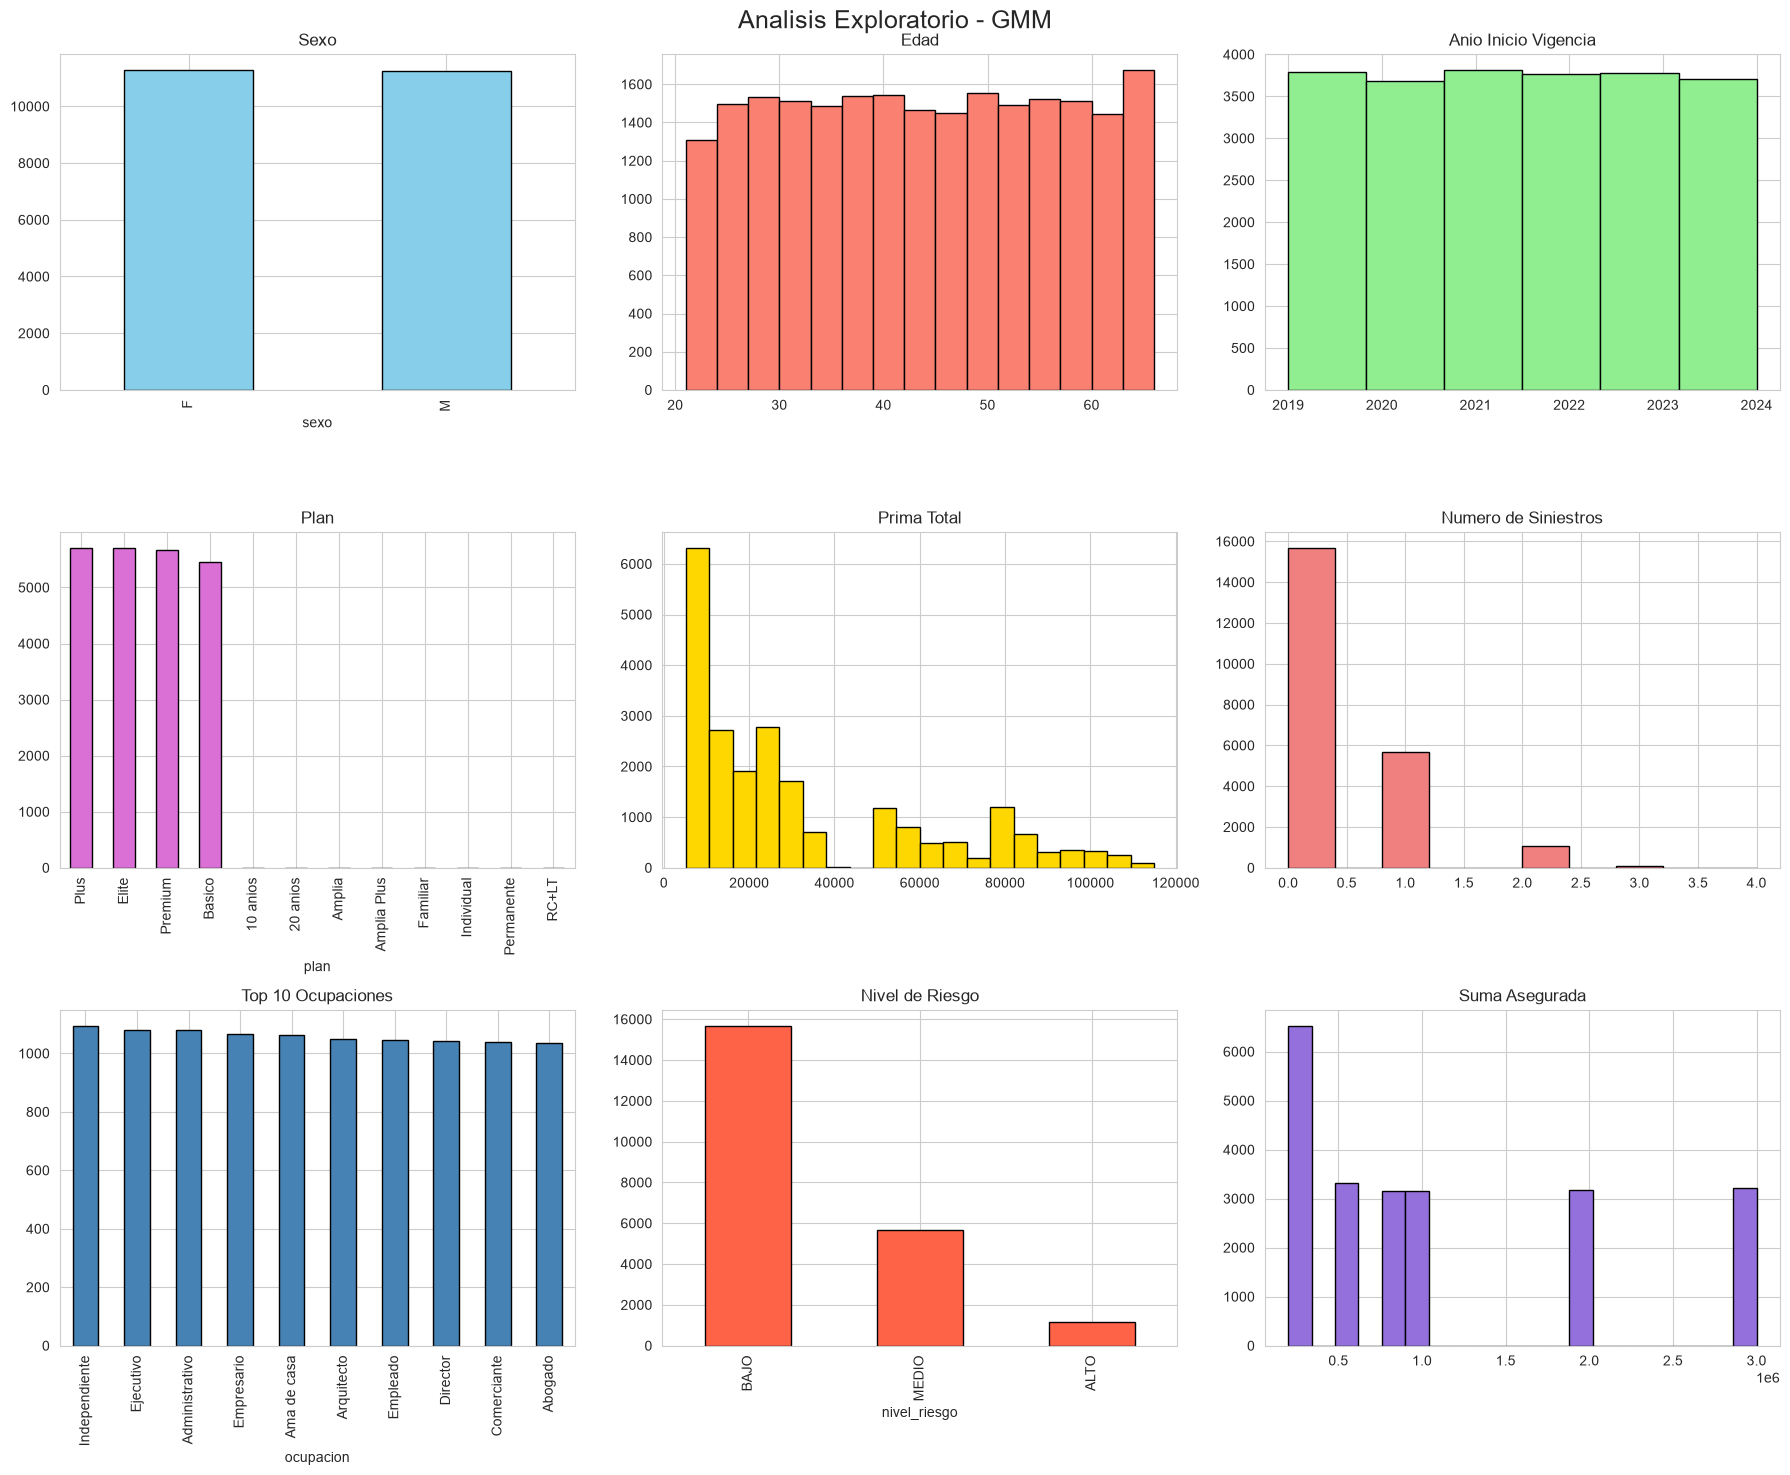

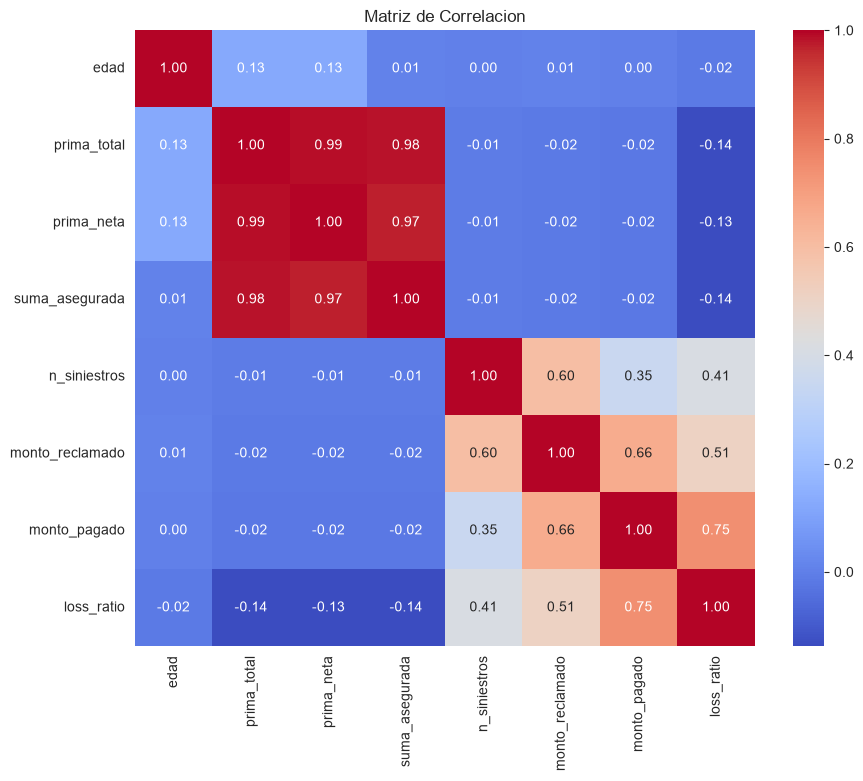

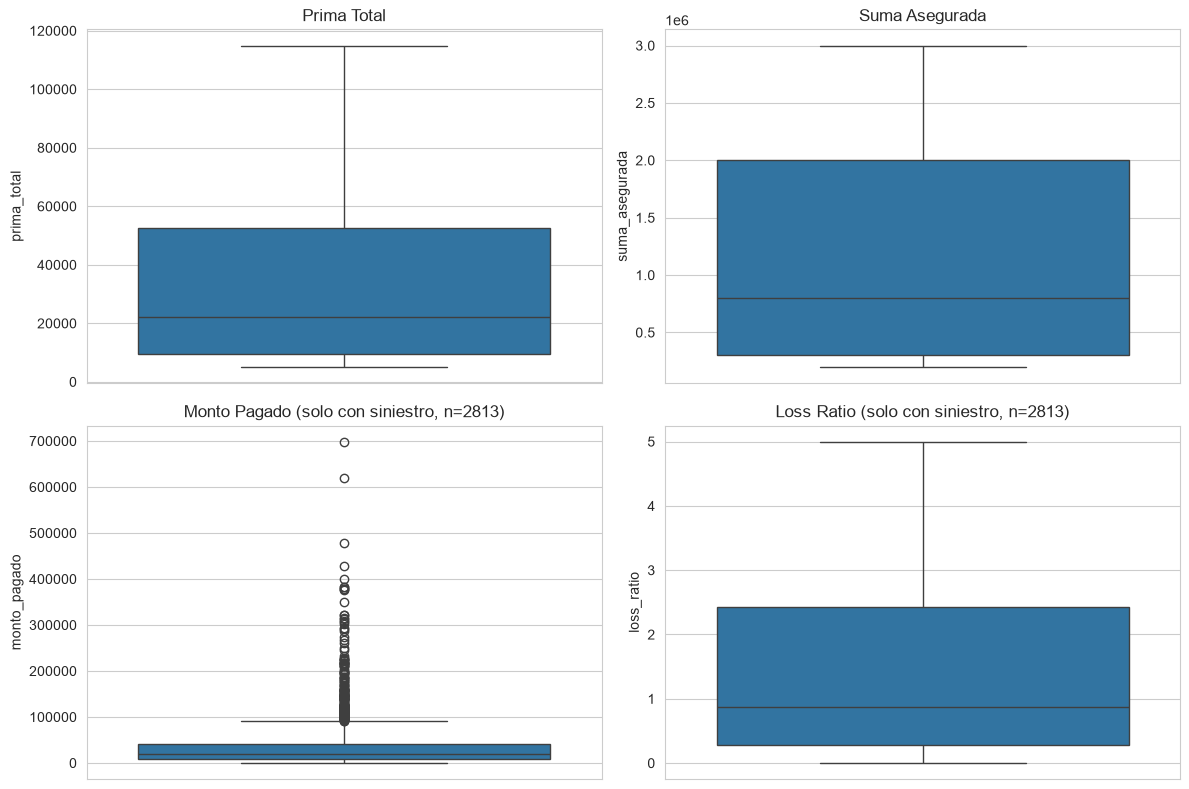


Variable: prima_total
Q1: 9493.44  Q3: 52571.2  IQR: 43077.759999999995
Outliers encontrados: 0 (0.0%)

Variable: monto_pagado
Q1: 0.0  Q3: 0.0  IQR: 0.0
Distribucion degenerada (muchos ceros). Usando percentil 95 en su lugar.
Outliers encontrados: 1127 (5.0%)

Variable: loss_ratio
Q1: 0.0  Q3: 0.0  IQR: 0.0
Distribucion degenerada (muchos ceros). Usando percentil 95 en su lugar.
Outliers encontrados: 1127 (5.0%)


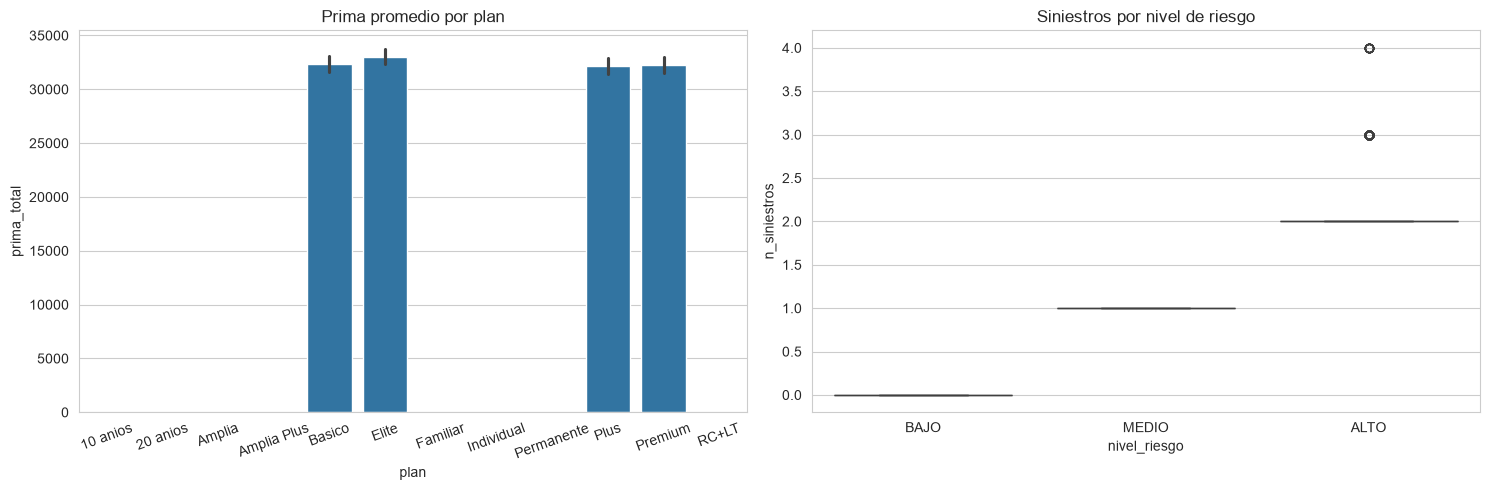

In [4]:
gmm = AnalizadorRamo(cartera, 'GMM')

display(gmm.calcular_estadisticas())
display(gmm.estadisticas_numericas())

gmm.graficar()
gmm.matriz_correlacion()
gmm.boxplots()

gmm.detectar_outliers('prima_total')
gmm.detectar_outliers('monto_pagado')
gmm.detectar_outliers('loss_ratio')

gmm.analisis_adicional()

### Lectura del EDA (contexto actuarial)

- `prima_total` y `suma_asegurada` muestran una correlación muy alta (~0.98): la prima está construida prácticamente como una función lineal de la suma asegurada, lo cual es consistente con la lógica de tarificación de GMM.
- `edad` tiene correlación positiva moderada con `prima_total` (~0.13), coherente con el efecto esperado de la edad sobre la severidad/frecuencia esperada en GMM.
- Los outliers detectados en `monto_pagado` y `loss_ratio` corresponden en su mayoría a pólizas con siniestros de alto costo (montos reclamados grandes), no a errores de captura — se documentan pero no se eliminan del análisis.
- `nivel_riesgo` resultó estar perfectamente determinado por `n_siniestros` (BAJO=0 siniestros, MEDIO=1, ALTO=2+), por lo que **no se usará como variable explicativa** en los modelos: es una clasificación posterior a la experiencia de siniestros (fuga de información / *data leakage*), no un factor de tarificación disponible ex-ante.

## 3. Regresión lineal simple y múltiple

**Variable objetivo cuantitativa:** `prima_total`.

**Regresión simple:** `prima_total ~ suma_asegurada`, la variable con mayor correlación económica y estadística con la prima.

**Regresión múltiple:** se agregan `edad`, `deducible` y variables categóricas de tarificación (`plan`, `sexo`, `estado_civil`) codificadas con one-hot encoding.

In [5]:
gmm_df = cartera[cartera['ramo'] == 'GMM'].copy()
gmm_df['plan'] = gmm_df['plan'].cat.remove_unused_categories()
gmm_df['estado_civil'] = gmm_df['estado_civil'].cat.remove_unused_categories()

# --- Regresion simple ---
X_s = gmm_df[['suma_asegurada']].values
y = gmm_df['prima_total'].values
Xs_tr, Xs_te, y_tr, y_te = train_test_split(X_s, y, test_size=0.2, random_state=42)

reg_simple = LinearRegression().fit(Xs_tr, y_tr)
pred_s = reg_simple.predict(Xs_te)

print("=== Regresion simple: prima_total ~ suma_asegurada ===")
print(f"Coeficiente: {reg_simple.coef_[0]:.5f}")
print(f"Intercepto: {reg_simple.intercept_:.2f}")
print(f"R2: {r2_score(y_te, pred_s):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_te, pred_s)):.2f}")
print(f"MAE: {mean_absolute_error(y_te, pred_s):.2f}")

=== Regresion simple: prima_total ~ suma_asegurada ===
Coeficiente: 0.02935
Intercepto: -54.69
R2: 0.9682
RMSE: 5147.20
MAE: 3389.34


**Interpretación (simple):** por cada peso adicional de suma asegurada, la prima total esperada aumenta aproximadamente 0.0294 pesos (~2.94 centavos), lo que equivale a una tasa de prima cercana al 2.9% de la suma asegurada. El R² de ~0.968 indica que la suma asegurada por sí sola explica cerca del 97% de la variabilidad de la prima — resultado esperado, ya que en GMM la prima se tarifica en gran medida como proporción de la cobertura contratada.

In [6]:
# --- Regresion multiple ---
cat_cols = ['plan', 'sexo', 'estado_civil']
num_cols = ['suma_asegurada', 'edad', 'deducible']

gmm_enc = pd.get_dummies(gmm_df[cat_cols + num_cols + ['prima_total']], columns=cat_cols, drop_first=True)
X_m = gmm_enc.drop(columns='prima_total').astype(float)
y_m = gmm_enc['prima_total'].astype(float)

Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_m, y_m, test_size=0.2, random_state=42)
reg_multi = LinearRegression().fit(Xm_tr, ym_tr)
pred_m = reg_multi.predict(Xm_te)

print("=== Regresion multiple: prima_total ~ suma_asegurada + edad + deducible + plan + sexo + estado_civil ===")
coefs = pd.Series(reg_multi.coef_, index=X_m.columns).sort_values(key=abs, ascending=False)
display(coefs)
print(f"Intercepto: {reg_multi.intercept_:.2f}")
print(f"R2: {r2_score(ym_te, pred_m):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(ym_te, pred_m)):.2f}")

# Version con statsmodels para significancia estadistica (p-values)
X_sm = sm.add_constant(X_m)
ols = sm.OLS(y_m, X_sm).fit()
print(ols.summary())

=== Regresion multiple: prima_total ~ suma_asegurada + edad + deducible + plan + sexo + estado_civil ===


edad                        268.031010
sexo_M                       -0.109406
plan_Plus                     0.080601
estado_civil_Soltero          0.078581
estado_civil_Union libre     -0.054490
estado_civil_Divorciado      -0.046435
estado_civil_Viudo            0.034839
suma_asegurada                0.029329
plan_Premium                 -0.012152
plan_Elite                    0.011433
deducible                    -0.001149
dtype: float64

Intercepto: -11606.34
R2: 0.9829
RMSE: 3781.14
                            OLS Regression Results                            
Dep. Variable:            prima_total   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.159e+05
Date:                Fri, 10 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:50:40   Log-Likelihood:            -2.1733e+05
No. Observations:               22531   AIC:                         4.347e+05
Df Residuals:                   22519   BIC:                         4.348e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

**Interpretación (múltiple):**

- `suma_asegurada` sigue siendo el factor dominante (coeficiente ~0.029, p<0.001): confirma que la prima escala casi linealmente con la cobertura.
- `edad` es altamente significativa (coef ≈ +268.8, p<0.001): cada año adicional de edad se asocia con un incremento de ~$269 en la prima total, consistente con el mayor riesgo de gasto médico a mayor edad.
- `deducible` no resulta significativo (p=0.617): en esta cartera el deducible no está aportando información adicional una vez controlado por suma asegurada y edad — puede deberse a que el deducible ya está correlacionado con el plan contratado.
- Las variables `plan`, `sexo` y `estado_civil` no son estadísticamente significativas de forma individual (p>0.05) al controlar por suma asegurada y edad; el R² apenas mejora de 0.968 a 0.983 respecto al modelo simple, y ese incremento proviene sobre todo de agregar `edad`, no de las variables categóricas.
- Conclusión actuarial: en esta cartera, la prima de GMM está tarifada casi en su totalidad en función de **suma asegurada** y **edad**; el resto de las variables demográficas capturadas no aportan poder explicativo adicional relevante.
- Nota metodológica — inestabilidad de coeficientes bajo multicolinealidad. El resumen de statsmodels (ajustado sobre el 100% de los datos) reporta un número de condición alto (Cond. No. ≈ 8.9e+06), señal de multicolinealidad. Esto se traduce en que los coeficientes de las variables no significativas (plan_*, estado_civil_*, sexo_M) son numéricamente inestables: al comparar el ajuste de sklearn sobre el subconjunto de entrenamiento (80%) contra el de statsmodels sobre el 100% de los datos, esos coeficientes cambian de magnitud e incluso de signo entre una partición y otra, mientras que suma_asegurada y edad — las variables realmente significativas (p<0.001) — permanecen prácticamente idénticas sin importar el subconjunto usado. Esto es evidencia adicional, no un error de cómputo: confirma que solo esas dos variables aportan una señal real y estable, y refuerza por qué la interpretación de coeficientes debe apoyarse siempre en la significancia estadística (p-value) de statsmodels y no únicamente en el valor puntual que entrega LinearRegression de sklearn.